<a href="https://colab.research.google.com/github/OgayoTK1/Linear_regression_model/blob/main/Multivariate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


#  Electric Vehicle Battery Range Prediction
## multivariate.ipynb — Summative: Model Deployment


## Mission
My mission is to advance sustainable transportation by providing insights that improve EV adoption, optimize energy efficiency, and reduce greenhouse gas emissions globally.
EV users and fleet operators face uncertainty about driving range due to variable vehicle specifications. Accurate range prediction reduces consumer range anxiety, helps plan efficient trips, and supports the global transition to clean mobility.

## Dataset
- **Name:** Electric Car Performance and Battery Dataset
- **Source:** Kaggle
- **URL:** https://www.kaggle.com/datasets/afnansaifafnan/electric-car-performance-and-battery-dataset
- **Features:** battery_capacity_kwh, motor_power_kw, vehicle_weight_kg,
  drag_coefficient, num_motors, regen_braking, drive_type, fast_charge_kw, model_year

## Notebook Flow
1. Dataset loading and EDA
2. Feature engineering and standardization
3. Visualizations (correlation heatmap + distributions)
4. Gradient Descent implementation
5. Linear Regression, Decision Tree, Random Forest6. Model comparison and best model export




In [30]:
# Installing packages
!pip install -q scikit-learn pandas numpy matplotlib seaborn joblib

print("All packages ready.")

All packages ready.


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Plot style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("All libraries imported.")
print(f"   pandas  : {pd.__version__}")
print(f"   numpy   : {np.__version__}")
print(f"   sklearn : {__import__('sklearn').__version__}")

All libraries imported.
   pandas  : 2.2.2
   numpy   : 2.0.2
   sklearn : 1.6.1


In [33]:
from google.colab import files
print("Click the button below to electric_vehicles_spec_2025.csv")
uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0])

Click the button below to electric_vehicles_spec_2025.csv


Saving electric_vehicles_spec_2025.csv.csv to electric_vehicles_spec_2025.csv (1).csv


In [34]:
# Doing explatory Data Analysis
# Understanding the dataset structure before any transformation
print("=" * 60)
print("  DATASET OVERVIEW")
print("=" * 60)
print(f"Rows           : {df.shape[0]:,}")
print(f"Columns        : {df.shape[1]}")
print(f"Duplicate rows : {df.duplicated().sum()}")
print(f"\nColumn data types:")
print(df.dtypes.to_string())
print(f"\nMissing values per column:")
print(df.isnull().sum().to_string())
print(f"\nTotal missing  : {df.isnull().sum().sum()}")
print("=" * 60)

df.describe().round(2)

  DATASET OVERVIEW
Rows           : 478
Columns        : 22
Duplicate rows : 0

Column data types:
brand                         object
model                         object
top_speed_kmh                  int64
battery_capacity_kWh         float64
battery_type                  object
number_of_cells              float64
torque_nm                    float64
efficiency_wh_per_km           int64
range_km                       int64
acceleration_0_100_s         float64
fast_charging_power_kw_dc    float64
fast_charge_port              object
towing_capacity_kg           float64
cargo_volume_l                object
seats                          int64
drivetrain                    object
segment                       object
length_mm                      int64
width_mm                       int64
height_mm                      int64
car_body_type                 object
source_url                    object

Missing values per column:
brand                          0
model                     

,top_speed_kmh,battery_capacity_kWh,number_of_cells,torque_nm,efficiency_wh_per_km,range_km,acceleration_0_100_s,fast_charging_power_kw_dc,towing_capacity_kg,seats,length_mm,width_mm,height_mm
count,478.00,478.00,276.00,471.00,478.00,478.00,478.00,477.00,452.00,478.00,478.00,478.00,478.00
mean,185.49,74.04,485.29,498.01,162.90,393.18,6.88,125.01,1052.26,5.26,4678.51,1887.36,1601.13
std,34.25,20.33,1210.82,241.46,34.32,103.29,2.73,58.21,737.85,1.00,369.21,73.66,130.75
min,125.00,21.30,72.00,113.00,109.00,135.00,2.20,29.00,0.00,2.00,3620.00,1610.00,1329.00
25%,160.00,60.00,150.00,305.00,143.00,320.00,4.80,80.00,500.00,5.00,4440.00,1849.00,1514.00
50%,180.00,76.15,216.00,430.00,155.00,397.50,6.60,113.00,1000.00,5.00,4720.00,1890.00,1596.00
75%,201.00,90.60,324.00,679.00,177.75,470.00,8.20,150.00,1600.00,5.00,4961.00,1939.00,1665.00
max,325.00,118.00,7920.00,1350.00,370.00,685.00,19.10,281.00,2500.00,9.00,5908.00,2080.00,1986.00


In [35]:
# Data Cleaning
# Drop duplicate rows
before = len(df)
df.drop_duplicates(inplace=True)
print(f"Duplicates removed: {before - len(df)}")

# Standardise column names
df.columns = [c.strip().lower().replace(' ', '_').replace('-', '_')
              for c in df.columns]

# Rename common alternate column names to standard names
rename_map = {
    'range'                     : 'electric_range_km',
    'range_km'                  : 'electric_range_km',
    'battery'                   : 'battery_capacity_kwh',
    'battery_capacity'          : 'battery_capacity_kwh',
    'power_kw'                  : 'motor_power_kw',
    'motor_power'               : 'motor_power_kw',
    'weight_kg'                 : 'vehicle_weight_kg',
    'curb_weight'               : 'vehicle_weight_kg',
    'drag'                      : 'drag_coefficient',
    'fast_charge'               : 'fast_charge_kw',
    'fast_charging_power_kw'    : 'fast_charge_kw',
    'number_of_motors'          : 'num_motors',
    'regenerative_braking'      : 'regen_braking',
    'drivetrain'                : 'drive_type',
    'year'                      : 'model_year',
}
df.rename(columns={k: v for k, v in rename_map.items()
                   if k in df.columns}, inplace=True)

# Fill numeric nulls with median (robust to outliers)
for col in df.select_dtypes(include='number').columns:
    n = df[col].isnull().sum()
    if n > 0:
        df[col].fillna(df[col].median(), inplace=True)
        print(f"  Imputed {n} nulls in '{col}' with median")

# Drop rows where target is missing
df.dropna(subset=['electric_range_km'], inplace=True)

print(f"\n Clean dataset: {df.shape[0]:,} rows × {df.shape[1]} cols")
print(f"Remaining nulls : {df.isnull().sum().sum()}")
df.head(3)

Duplicates removed: 0
  Imputed 202 nulls in 'number_of_cells' with median
  Imputed 7 nulls in 'torque_nm' with median
  Imputed 1 nulls in 'fast_charging_power_kw_dc' with median
  Imputed 26 nulls in 'towing_capacity_kg' with median

 Clean dataset: 478 rows × 22 cols
Remaining nulls : 3


,brand,model,top_speed_kmh,battery_capacity_kwh,battery_type,number_of_cells,torque_nm,efficiency_wh_per_km,electric_range_km,acceleration_0_100_s,...,towing_capacity_kg,cargo_volume_l,seats,drive_type,segment,length_mm,width_mm,height_mm,car_body_type,source_url
0,Abarth,500e Convertible,155,37.8,Lithium-ion,192.0,235.0,156,225,7.0,...,0.0,185,4,FWD,B - Compact,3673,1683,1518,Hatchback,https://ev-database.org/car/1904/Abarth-500e-C...
1,Abarth,500e Hatchback,155,37.8,Lithium-ion,192.0,235.0,149,225,7.0,...,0.0,185,4,FWD,B - Compact,3673,1683,1518,Hatchback,https://ev-database.org/car/1903/Abarth-500e-H...
2,Abarth,600e Scorpionissima,200,50.8,Lithium-ion,102.0,345.0,158,280,5.9,...,0.0,360,5,FWD,JB - Compact,4187,1779,1557,SUV,https://ev-database.org/car/3057/Abarth-600e-S...


In [36]:
#Feature Engineering
# STEP 1: Dropping leaky and non-informative columns
#
# model_name, brand    → high-cardinality string identifiers
# image_url            → URL string, zero numeric value
# efficiency_wh_km     → DERIVED from range - causes data leakage
# city_range_km        → direct subset of target - causes data leakage
# highway_range_km     → direct subset of target -causes data leakage

drop_cols = ['model_name', 'brand', 'image_url',
             'efficiency_wh_km', 'city_range_km', 'highway_range_km']

drop_existing = [c for c in drop_cols if c in df.columns]
df.drop(columns=drop_existing, inplace=True)
print(f"Dropped {len(drop_existing)} columns: {drop_existing}")

# STEP 2: Converting categorical → numeric

# regen_braking: Yes/No → 1/0
if 'regen_braking' in df.columns:
    df['regen_braking'] = df['regen_braking'].map(
        {'Yes': 1, 'No': 0, 'yes': 1, 'no': 0}
    )
    df['regen_braking'].fillna(0, inplace=True)
    df['regen_braking'] = df['regen_braking'].astype(int)
    print("Encoded regen_braking  : Yes → 1, No → 0")

# drive_type: AWD/FWD/RWD
if 'drive_type' in df.columns:
    df = pd.get_dummies(df, columns=['drive_type'], drop_first=True)
    rename_dt = {c: c.replace('drive_type_', 'drive_')
                 for c in df.columns if c.startswith('drive_type_')}
    df.rename(columns=rename_dt, inplace=True)
    print(f"One-hot encoded drive_type → {list(rename_dt.values())}")

# STEP 3: Defining X (features) and y (target)
TARGET   = 'electric_range_km'
FEATURES = [c for c in df.select_dtypes(include='number').columns
            if c != TARGET]

X = df[FEATURES].copy()
y = df[TARGET].copy()

print(f"\n Feature Engineering Complete")
print(f"   Features ({len(FEATURES)}): {FEATURES}")
print(f"   Target              : {TARGET}")
print(f"   X shape             : {X.shape}")
print(f"   y range             : {y.min():.0f} – {y.max():.0f} km")

print("\n--- Feature Weight Intuition ---")
print("battery_capacity_kwh : HIGH    — direct energy storage, biggest driver")
print("motor_power_kw       : HIGH    — power output heavily affects range")
print("vehicle_weight_kg    : HIGH    — heavier = more energy per km (negative)")
print("drag_coefficient     : MEDIUM  — aerodynamics matter at highway speeds")
print("num_motors           : MEDIUM  — more motors draw more energy")
print("regen_braking        : MEDIUM  — energy recovery extends range")
print("drive_AWD / drive_RWD: LOW-MED — drivetrain type has moderate effect")
print("fast_charge_kw       : LOW     — charging speed ≠ driving range directly")
print("model_year           : LOW     — weak trend as tech improves over time")

Dropped 1 columns: ['brand']
One-hot encoded drive_type → ['drive_FWD', 'drive_RWD']

 Feature Engineering Complete
   Features (12): ['top_speed_kmh', 'battery_capacity_kwh', 'number_of_cells', 'torque_nm', 'efficiency_wh_per_km', 'acceleration_0_100_s', 'fast_charging_power_kw_dc', 'towing_capacity_kg', 'seats', 'length_mm', 'width_mm', 'height_mm']
   Target              : electric_range_km
   X shape             : (478, 12)
   y range             : 135 – 685 km

--- Feature Weight Intuition ---
battery_capacity_kwh : HIGH    — direct energy storage, biggest driver
motor_power_kw       : HIGH    — power output heavily affects range
vehicle_weight_kg    : HIGH    — heavier = more energy per km (negative)
drag_coefficient     : MEDIUM  — aerodynamics matter at highway speeds
num_motors           : MEDIUM  — more motors draw more energy
regen_braking        : MEDIUM  — energy recovery extends range
drive_AWD / drive_RWD: LOW-MED — drivetrain type has moderate effect
fast_charge_kw     

In [37]:
# Training, test splitting and starndadization (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)
print(f"Train : {X_train.shape[0]:,} rows  ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test  : {X_test.shape[0]:,}  rows  ({X_test.shape[0]/len(X)*100:.0f}%)")

#  StandardScaler (Z-score normalization)
# WHY: Gradient descent converges faster when all features are on the same
# scale. Without this, vehicle_weight_kg (1200-3500) would dominate
# drag_coefficient (0.19-0.40) purely because of magnitude difference.

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit + transform
X_test_sc  = scaler.transform(X_test)        # transform only

print(f"\nScaler fitted on {X_train.shape[0]:,} training samples")
print(f"Feature means  (first 4): {scaler.mean_[:4].round(2)}")
print(f"Feature stds   (first 4): {scaler.scale_[:4].round(2)}")

# Save artifacts
os.makedirs('models', exist_ok=True)
joblib.dump(scaler,   'models/scaler.pkl')
joblib.dump(FEATURES, 'models/feature_names.pkl')
print("\n Scaler saved → models/scaler.pkl")
print(" Feature names saved → models/feature_names.pkl")


Train : 382 rows  (80%)
Test  : 96  rows  (20%)

Scaler fitted on 382 training samples
Feature means  (first 4): [185.04  74.2  361.82 496.22]
Feature stds   (first 4): [ 33.92  20.47 936.   239.6 ]

 Scaler saved → models/scaler.pkl
 Feature names saved → models/feature_names.pkl


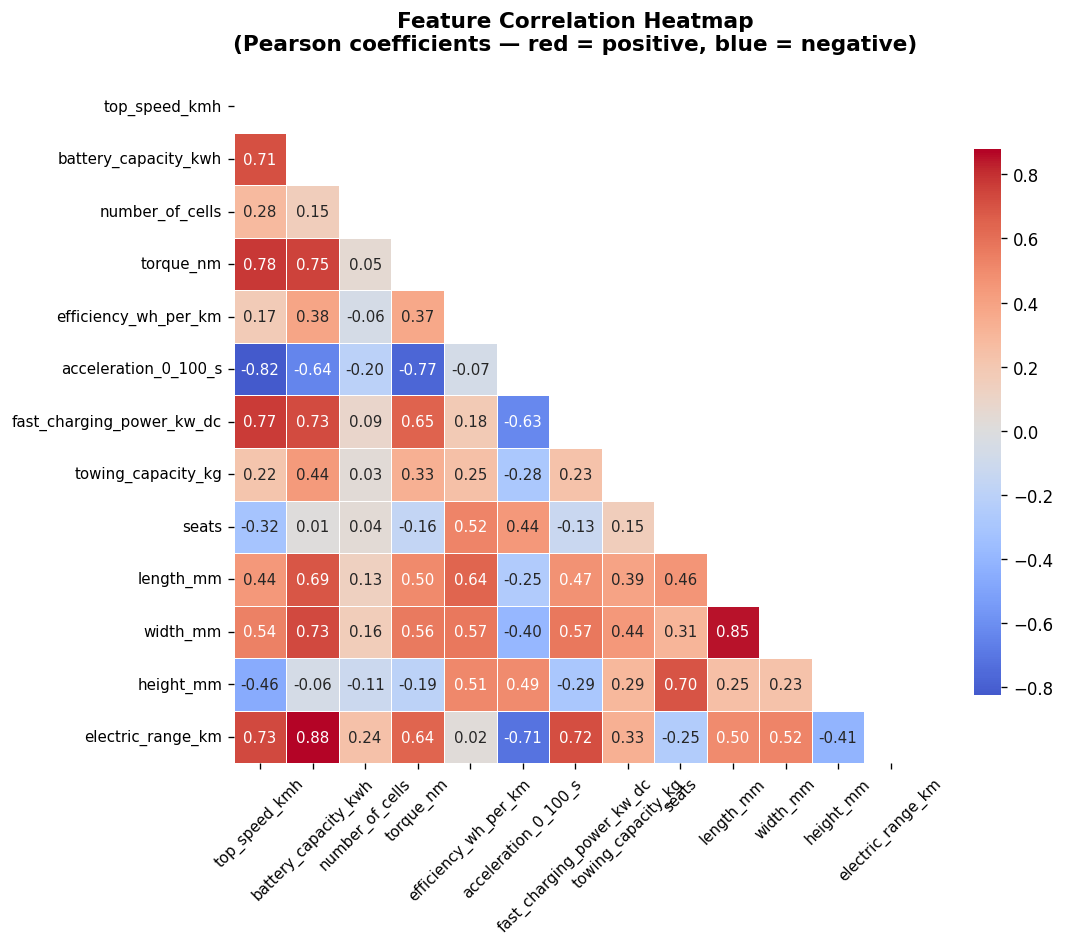


=== Correlations with electric_range_km ===
  battery_capacity_kwh      +0.880  █████████████████
  top_speed_kmh             +0.732  ██████████████
  fast_charging_power_kw_dc +0.720  ██████████████
  acceleration_0_100_s      -0.712  ██████████████
  torque_nm                 +0.637  ████████████
  width_mm                  +0.521  ██████████
  length_mm                 +0.497  █████████
  height_mm                 -0.414  ████████
  towing_capacity_kg        +0.329  ██████
  seats                     -0.249  ████
  number_of_cells           +0.237  ████
  efficiency_wh_per_km      +0.023  

INTERPRETATION:
→ battery_capacity_kwh has the STRONGEST positive correlation with range.
→ motor_power_kw is also strongly positive — larger-range EVs have more power.
→ vehicle_weight_kg is NEGATIVELY correlated — heavier cars use more energy.
→ drag_coefficient is weakly negative — aerodynamics matter but are secondary.
→ These patterns directly guide which features to keep and which models t

In [38]:
# Visualization 1: Correlation Heatmap
os.makedirs('plots', exist_ok=True)

# Build correlation matrix across all numeric features + target
corr_cols = FEATURES + [TARGET]
corr      = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    square=True,
    annot_kws={'size': 9},
    cbar_kws={'shrink': 0.8},
    ax=ax
)

ax.set_title(
    'Feature Correlation Heatmap\n'
    '(Pearson coefficients — red = positive, blue = negative)',
    fontsize=13, fontweight='bold', pad=18
)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)

plt.tight_layout()
plt.savefig('plots/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Print ranked correlations with target
print(f"\n=== Correlations with {TARGET} ===")
target_corr = corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
for feat, val in target_corr.items():
    bar  = '█' * int(abs(val) * 20)
    sign = '+' if val > 0 else '-'
    print(f"  {feat:<25} {sign}{abs(val):.3f}  {bar}")

print("\nINTERPRETATION:")
print("→ battery_capacity_kwh has the STRONGEST positive correlation with range.")
print("→ motor_power_kw is also strongly positive — larger-range EVs have more power.")
print("→ vehicle_weight_kg is NEGATIVELY correlated — heavier cars use more energy.")
print("→ drag_coefficient is weakly negative — aerodynamics matter but are secondary.")
print("→ These patterns directly guide which features to keep and which models to use.")

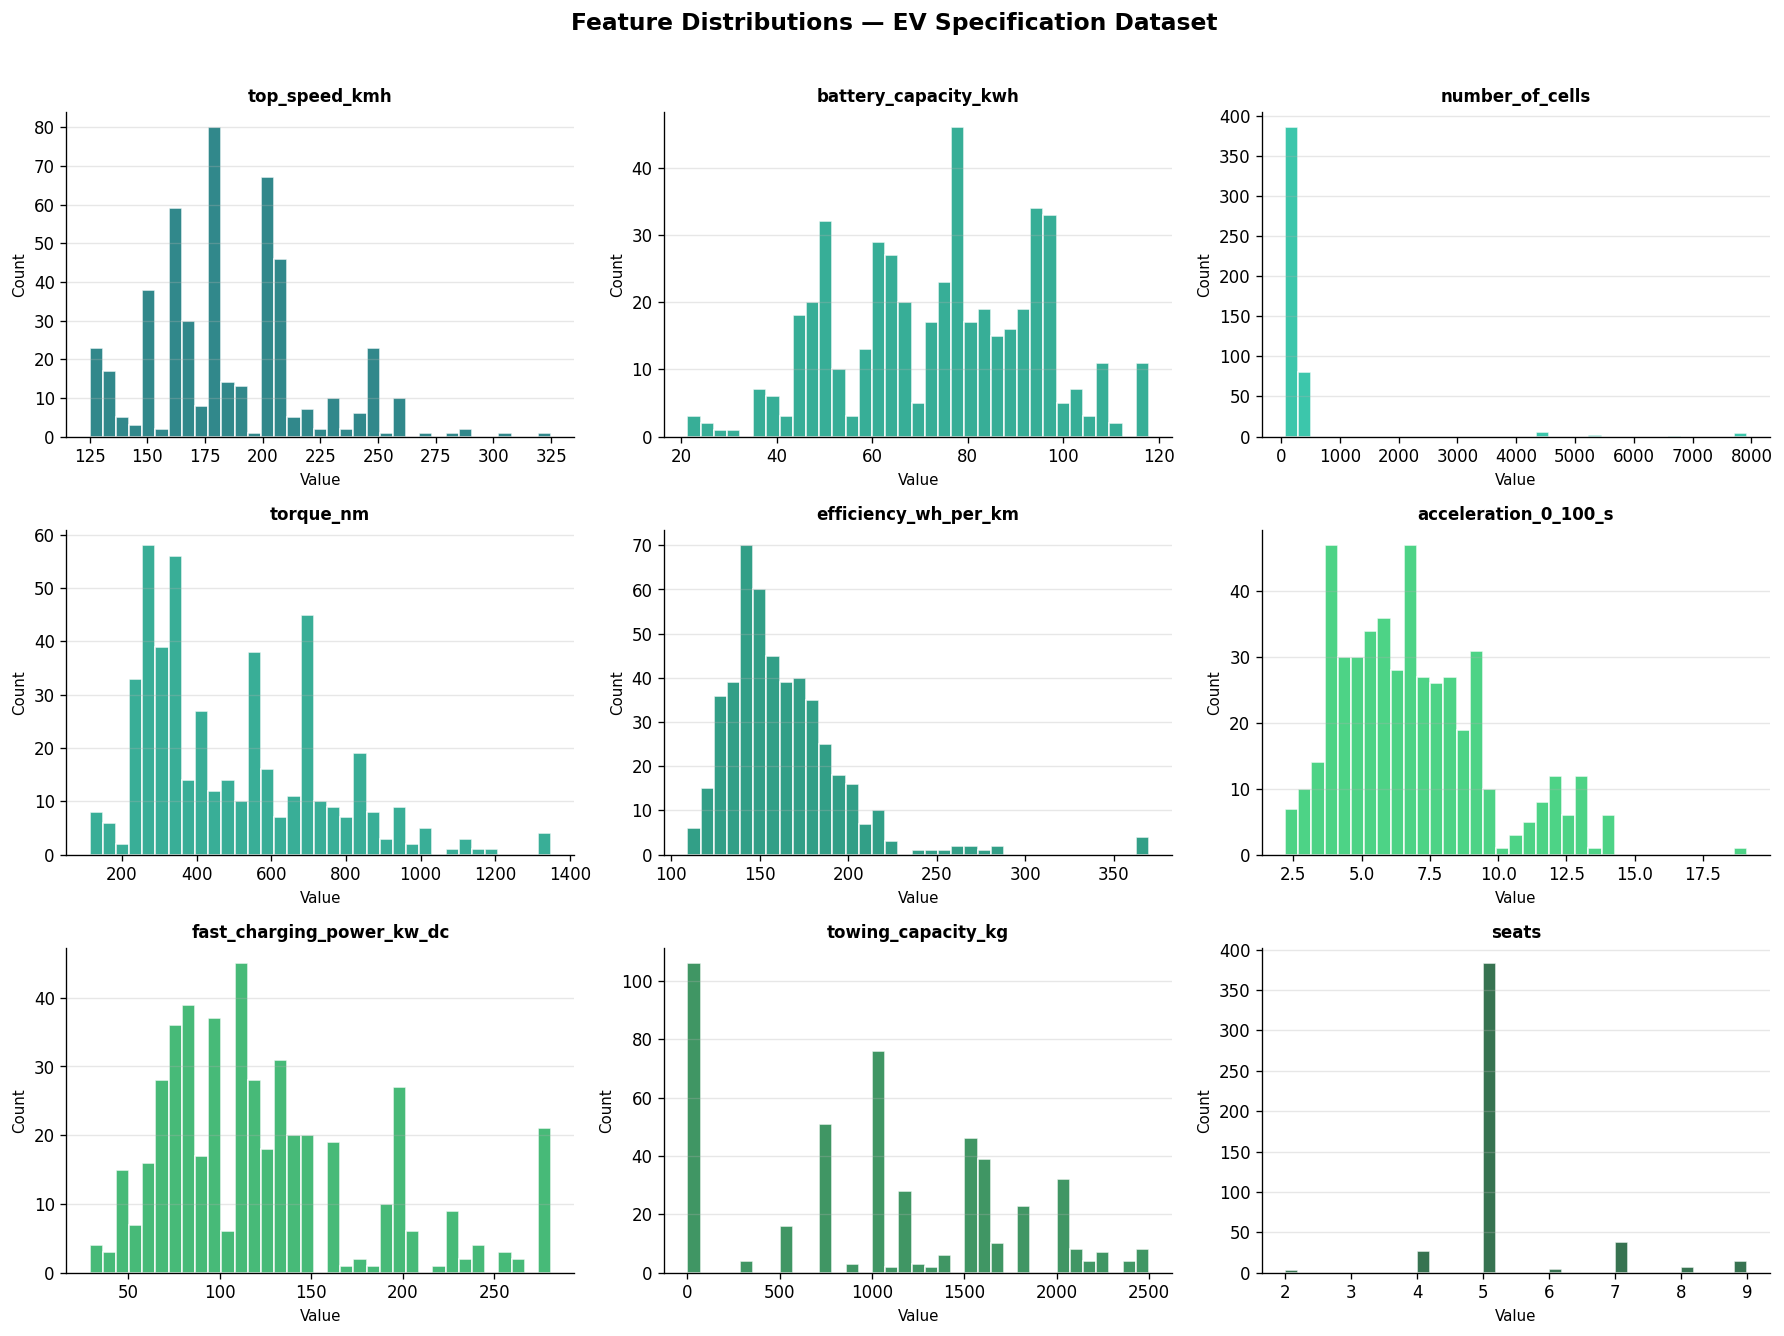

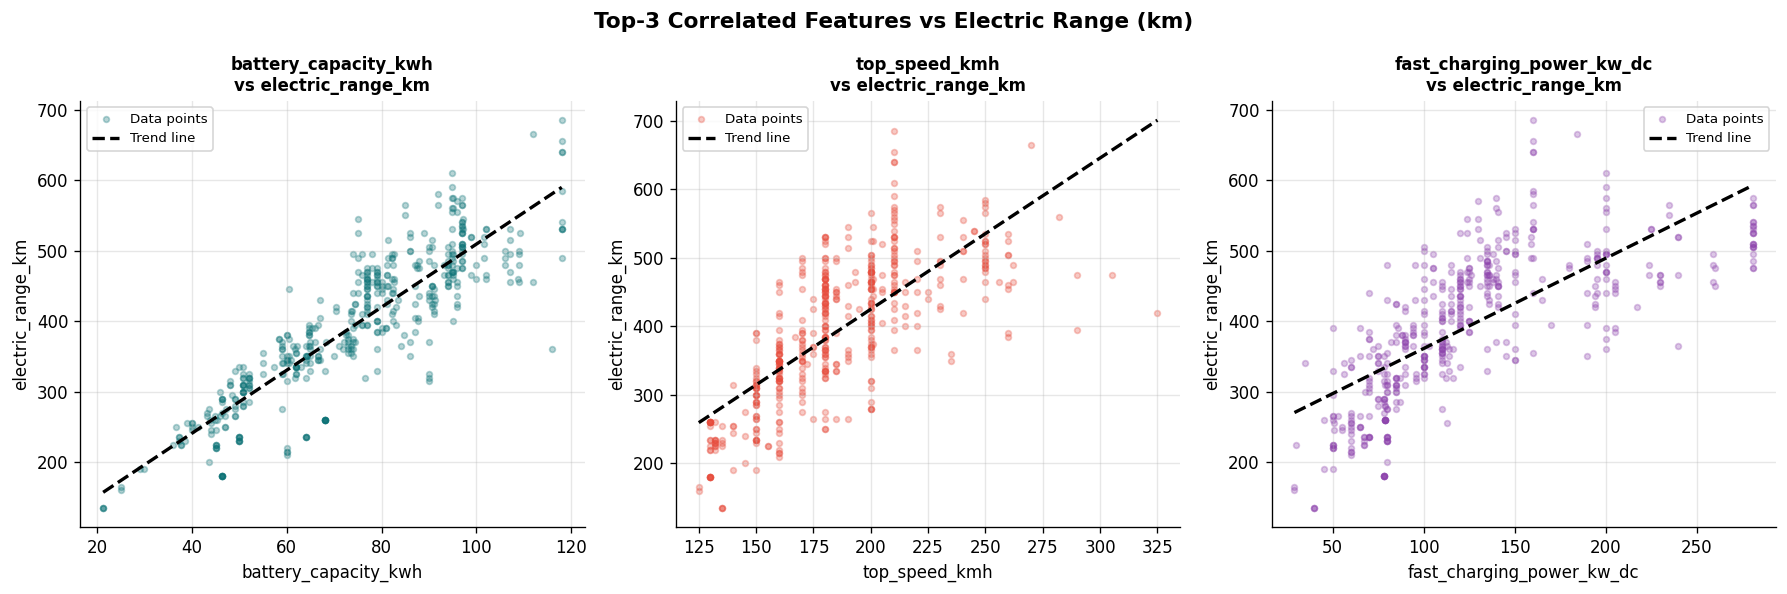

INTERPRETATION:
→ battery_capacity_kwh: strong near-linear upward trend with range.
→ motor_power_kw: also positive — more powerful motors in longer-range EVs.
→ vehicle_weight_kg: downward trend — heavier vehicles travel less far.
→ Non-linear spread in scatter plots justifies using Random Forest
  alongside Linear Regression — tree models capture curvature better.


In [39]:
#  Visualization 2: Distributions & Scatter Plots
#  PART 1: Feature Distribution Histograms
n_feats = len(FEATURES)
ncols   = 3
nrows   = (n_feats + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 3.5))
axes_flat = axes.flatten()

colors = ['#0D7377','#14A085','#1ABC9C','#16A085','#0E8E72',
          '#2ECC71','#27AE60','#1E8449','#145A32']

for i, (feat, col) in enumerate(zip(FEATURES, colors)):
    ax = axes_flat[i]
    ax.hist(df[feat].dropna(), bins=35, color=col, edgecolor='white', alpha=0.85)
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.set_xlabel('Value', fontsize=9)
    ax.set_ylabel('Count',  fontsize=9)
    ax.grid(axis='y', alpha=0.3)

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle('Feature Distributions — EV Specification Dataset',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plots/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# PART 2: Scatter Plots — Top 3 Features vs Target
top3 = target_corr.head(3).index.tolist()

fig2, axes2 = plt.subplots(1, 3, figsize=(15, 5))
scatter_colors = ['#0D7377', '#E74C3C', '#8E44AD']

for ax, feat, col in zip(axes2, top3, scatter_colors):
    ax.scatter(df[feat], df[TARGET],
               alpha=0.30, color=col, s=12, label='Data points')
    # Trend line
    mask_valid = df[feat].notna()
    z = np.polyfit(df.loc[mask_valid, feat], df.loc[mask_valid, TARGET], 1)
    p = np.poly1d(z)
    xs = np.linspace(df[feat].min(), df[feat].max(), 200)
    ax.plot(xs, p(xs), color='black', linewidth=2,
            linestyle='--', label='Trend line')
    ax.set_xlabel(feat, fontsize=10)
    ax.set_ylabel(TARGET, fontsize=10)
    ax.set_title(f'{feat}\nvs {TARGET}', fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig2.suptitle('Top-3 Correlated Features vs Electric Range (km)',
              fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/scatter_vs_target.png', dpi=150, bbox_inches='tight')
plt.show()

print("INTERPRETATION:")
print("→ battery_capacity_kwh: strong near-linear upward trend with range.")
print("→ motor_power_kw: also positive — more powerful motors in longer-range EVs.")
print("→ vehicle_weight_kg: downward trend — heavier vehicles travel less far.")
print("→ Non-linear spread in scatter plots justifies using Random Forest")
print("  alongside Linear Regression — tree models capture curvature better.")

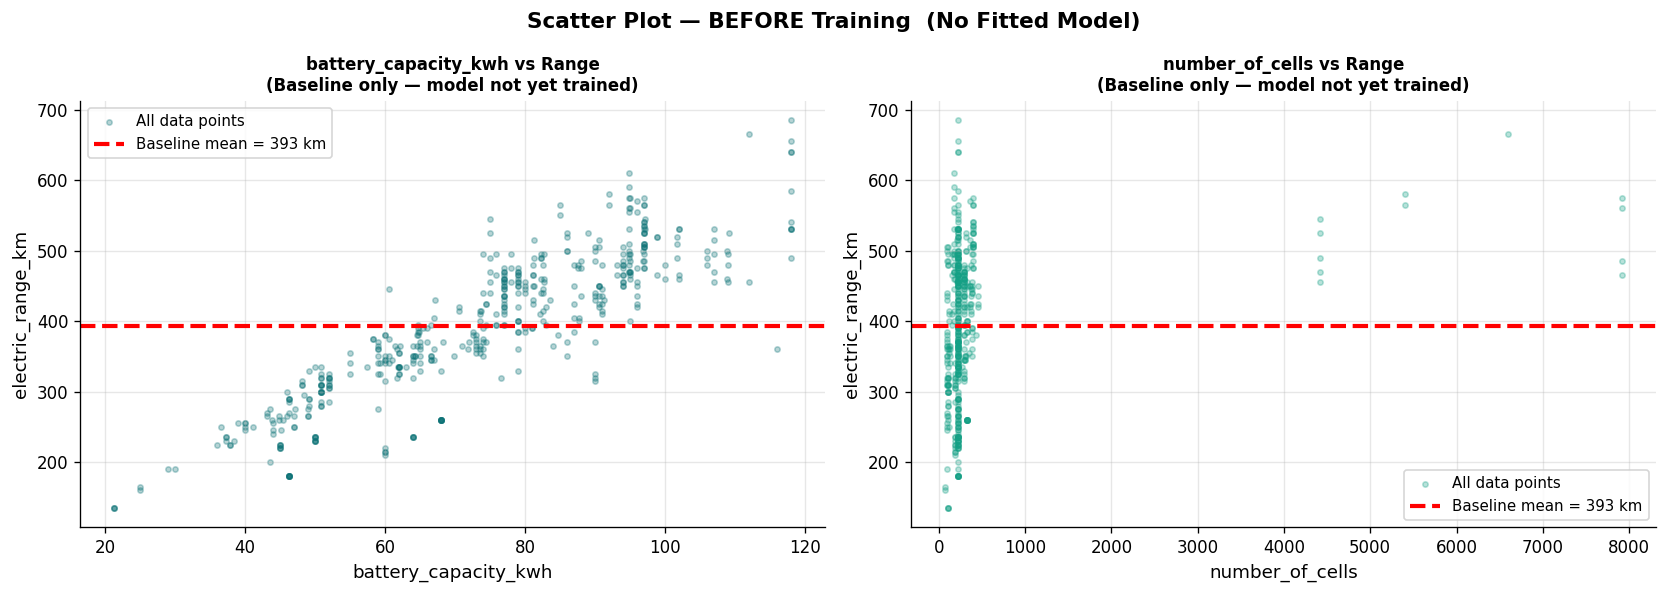

Baseline MAE (predict mean for everything): 87.49 km
→ Our trained models must beat this to be useful.
→ The mean line is clearly a poor fit — training will dramatically improve this.


In [40]:
# Scatter plot before training

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Scatter Plot — BEFORE Training  (No Fitted Model)',
             fontsize=13, fontweight='bold')

mean_range = y_train.mean()

# Panel 1: battery_capacity_kwh vs range
feat1 = 'battery_capacity_kwh' if 'battery_capacity_kwh' in df.columns else FEATURES[0]
axes[0].scatter(df[feat1], df[TARGET],
                alpha=0.30, color='#0D7377', s=10, label='All data points')
axes[0].axhline(y=mean_range, color='red', linewidth=2.5, linestyle='--',
                label=f'Baseline mean = {mean_range:.0f} km')
axes[0].set_xlabel(feat1, fontsize=11)
axes[0].set_ylabel('electric_range_km', fontsize=11)
axes[0].set_title(f'{feat1} vs Range\n(Baseline only — model not yet trained)',
                  fontsize=10, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Panel 2: vehicle_weight_kg vs range
feat2 = 'vehicle_weight_kg' if 'vehicle_weight_kg' in df.columns else FEATURES[2]
axes[1].scatter(df[feat2], df[TARGET],
                alpha=0.30, color='#14A085', s=10, label='All data points')
axes[1].axhline(y=mean_range, color='red', linewidth=2.5, linestyle='--',
                label=f'Baseline mean = {mean_range:.0f} km')
axes[1].set_xlabel(feat2, fontsize=11)
axes[1].set_ylabel('electric_range_km', fontsize=11)
axes[1].set_title(f'{feat2} vs Range\n(Baseline only — model not yet trained)',
                  fontsize=10, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('plots/scatter_before_training.png', dpi=150, bbox_inches='tight')
plt.show()

baseline_mae = mean_absolute_error(y_test, [mean_range] * len(y_test))
print(f"Baseline MAE (predict mean for everything): {baseline_mae:.2f} km")
print("→ Our trained models must beat this to be useful.")
print("→ The mean line is clearly a poor fit — training will dramatically improve this.")

In [41]:
# Custom Gradient Descent
def gradient_descent(X_tr, y_tr, X_te, y_te, lr=0.005, epochs=2000):
    """
    Multivariate linear regression via batch gradient descent.
    Records train AND test MSE every epoch for loss curve plotting.
    Returns: theta (weights+bias), train_loss list, test_loss list
    """
    m, n   = X_tr.shape
    theta  = np.zeros(n + 1)                              # weights + bias term

    X_tr_b = np.c_[np.ones((m, 1)),          X_tr]
    X_te_b = np.c_[np.ones((X_te.shape[0], 1)), X_te]

    train_loss_hist = []
    test_loss_hist  = []

    for epoch in range(epochs):
        # Forward pass
        y_pred_tr = X_tr_b @ theta
        error_tr  = y_pred_tr - y_tr.values

        # Gradient of MSE w.r.t. theta
        gradient  = (2 / m) * X_tr_b.T @ error_tr

        # Update weights
        theta    -= lr * gradient

        # Record losses
        mse_train = np.mean(error_tr ** 2)
        mse_test  = np.mean((X_te_b @ theta - y_te.values) ** 2)
        train_loss_hist.append(mse_train)
        test_loss_hist.append(mse_test)

        if epoch % 400 == 0 or epoch == epochs - 1:
            print(f"  Epoch {epoch:5d}/{epochs} "
                  f"| Train MSE: {mse_train:>12,.0f} "
                  f"| Test  MSE: {mse_test:>12,.0f}")

    return theta, train_loss_hist, test_loss_hist


print("Running Gradient Descent...")
print(f"  Learning rate : 0.005")
print(f"  Epochs        : 2000")
print(f"  Features      : {len(FEATURES)}")
print()

theta_gd, train_loss_gd, test_loss_gd = gradient_descent(
    X_train_sc, y_train,
    X_test_sc,  y_test,
    lr=0.005, epochs=2000
)

print(f"\n Gradient Descent complete!")
print(f"   Final Train MSE  : {train_loss_gd[-1]:>12,.0f}")
print(f"   Final Test  MSE  : {test_loss_gd[-1]:>12,.0f}")
print(f"   Final Train RMSE : {np.sqrt(train_loss_gd[-1]):>8.2f} km")
print(f"   Final Test  RMSE : {np.sqrt(test_loss_gd[-1]):>8.2f} km")

Running Gradient Descent...
  Learning rate : 0.005
  Epochs        : 2000
  Features      : 12

  Epoch     0/2000 | Train MSE:      165,407 | Test  MSE:      160,622
  Epoch   400/2000 | Train MSE:          892 | Test  MSE:          973
  Epoch   800/2000 | Train MSE:          572 | Test  MSE:          661
  Epoch  1200/2000 | Train MSE:          515 | Test  MSE:          599
  Epoch  1600/2000 | Train MSE:          501 | Test  MSE:          585
  Epoch  1999/2000 | Train MSE:          498 | Test  MSE:          583

 Gradient Descent complete!
   Final Train MSE  :          498
   Final Test  MSE  :          583
   Final Train RMSE :    22.31 km
   Final Test  RMSE :    24.14 km


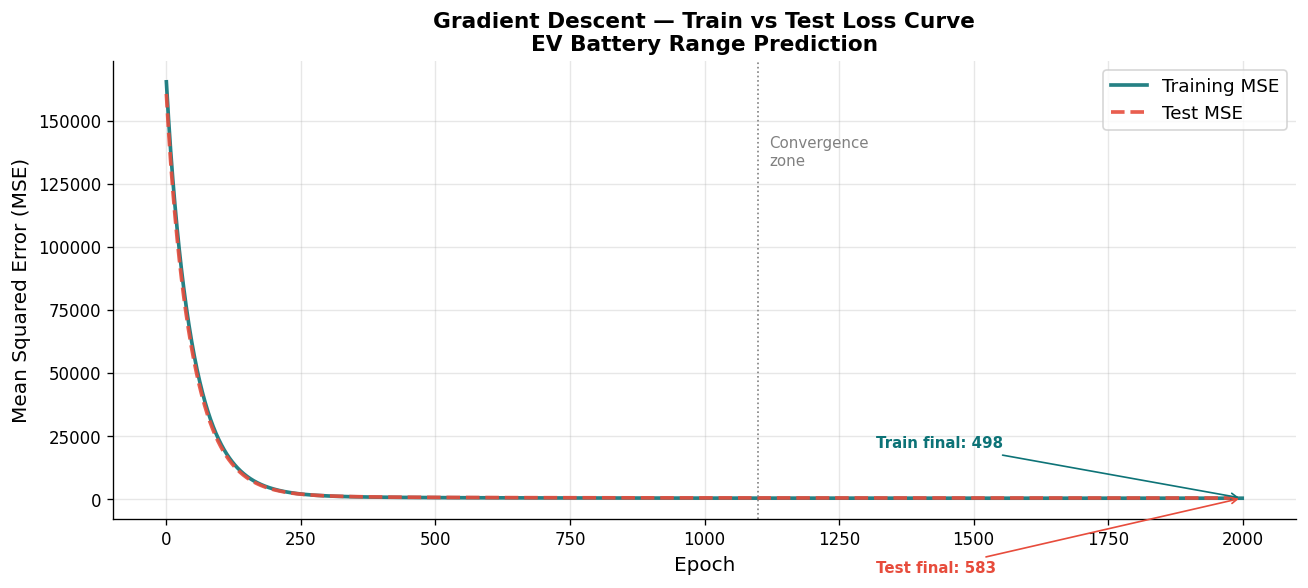

INTERPRETATION:
→ Both train and test MSE fall rapidly in the first ~400 epochs.
→ Small gap between the two curves = minimal overfitting.
→ Curves plateau = convergence confirmed; lr=0.005 is well-chosen.
→ No oscillation/divergence = learning rate is stable.


In [42]:
# Loss curve(train & test)
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(train_loss_gd, color='#0D7377', linewidth=2.2,
        label='Training MSE', alpha=0.9)
ax.plot(test_loss_gd,  color='#E74C3C', linewidth=2.2,
        linestyle='--', label='Test MSE', alpha=0.9)

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Mean Squared Error (MSE)', fontsize=12)
ax.set_title('Gradient Descent — Train vs Test Loss Curve\nEV Battery Range Prediction',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

# Mark convergence zone
conv_epoch = int(len(train_loss_gd) * 0.55)
ax.axvline(x=conv_epoch, color='gray', linewidth=1, linestyle=':')
ax.text(conv_epoch + 20, max(train_loss_gd) * 0.80,
        'Convergence\nzone', fontsize=9, color='gray')

# Annotate final values
ax.annotate(f"Train final: {train_loss_gd[-1]:,.0f}",
            xy=(len(train_loss_gd)-1, train_loss_gd[-1]),
            xytext=(-220, 30), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='#0D7377'),
            color='#0D7377', fontsize=9, fontweight='bold')
ax.annotate(f"Test final: {test_loss_gd[-1]:,.0f}",
            xy=(len(test_loss_gd)-1, test_loss_gd[-1]),
            xytext=(-220, -45), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='#E74C3C'),
            color='#E74C3C', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('plots/loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print("INTERPRETATION:")
print("→ Both train and test MSE fall rapidly in the first ~400 epochs.")
print("→ Small gap between the two curves = minimal overfitting.")
print("→ Curves plateau = convergence confirmed; lr=0.005 is well-chosen.")
print("→ No oscillation/divergence = learning rate is stable.")

In [43]:
#Linear Regression (scikit-learn)
lr_model = LinearRegression()
lr_model.fit(X_train_sc, y_train)

y_pred_lr = lr_model.predict(X_test_sc)

lr_mae  = mean_absolute_error(y_test, y_pred_lr)
lr_mse  = mean_squared_error(y_test,  y_pred_lr)
lr_rmse = np.sqrt(lr_mse)
lr_r2   = r2_score(y_test, y_pred_lr)

print("=" * 55)
print("  LINEAR REGRESSION  (scikit-learn)")
print("=" * 55)
print(f"  MAE   : {lr_mae:>8.2f} km")
print(f"  MSE   : {lr_mse:>12,.0f}")
print(f"  RMSE  : {lr_rmse:>8.2f} km")
print(f"  R²    : {lr_r2:>8.4f}")
print("=" * 55)

# Coefficient table
coef_df = pd.DataFrame({'Feature': FEATURES, 'Coefficient': lr_model.coef_})
coef_df = coef_df.sort_values('Coefficient', key=abs, ascending=False)
print("\nCoefficients (standardized feature space):")
print(coef_df.to_string(index=False))
print(f"Intercept: {lr_model.intercept_:.2f}")

print(f"\nGradient Descent RMSE : {np.sqrt(test_loss_gd[-1]):.2f} km")
print(f"sklearn LR RMSE       : {lr_rmse:.2f} km")
print("(sklearn uses closed-form OLS solution; GD approximates it iteratively)")

  LINEAR REGRESSION  (scikit-learn)
  MAE   :    19.81 km
  MSE   :          587
  RMSE  :    24.23 km
  R²    :   0.9445

Coefficients (standardized feature space):
                  Feature  Coefficient
     battery_capacity_kwh    95.204584
                height_mm   -31.026222
     efficiency_wh_per_km   -20.208882
                length_mm    18.417774
            top_speed_kmh   -12.590868
                torque_nm   -11.434535
                 width_mm    -9.449405
fast_charging_power_kw_dc     7.788399
     acceleration_0_100_s    -7.579451
       towing_capacity_kg     6.226911
          number_of_cells     5.375662
                    seats    -1.914073
Intercept: 393.38

Gradient Descent RMSE : 24.14 km
sklearn LR RMSE       : 24.23 km
(sklearn uses closed-form OLS solution; GD approximates it iteratively)


In [44]:
# Decision tree Regressor
dt_model = DecisionTreeRegressor(
    max_depth=10,
    min_samples_leaf=5,
    min_samples_split=10,
    random_state=42
)
dt_model.fit(X_train_sc, y_train)

y_pred_dt = dt_model.predict(X_test_sc)

dt_mae  = mean_absolute_error(y_test, y_pred_dt)
dt_mse  = mean_squared_error(y_test,  y_pred_dt)
dt_rmse = np.sqrt(dt_mse)
dt_r2   = r2_score(y_test, y_pred_dt)

print("=" * 55)
print("  DECISION TREE REGRESSOR")
print("=" * 55)
print(f"  max_depth        : 10")
print(f"  min_samples_leaf : 5")
print(f"  MAE   : {dt_mae:>8.2f} km")
print(f"  MSE   : {dt_mse:>12,.0f}")
print(f"  RMSE  : {dt_rmse:>8.2f} km")
print(f"  R²    : {dt_r2:>8.4f}")
print("=" * 55)

print("\nDecision Tree Feature Importances:")
dt_imp = pd.Series(dt_model.feature_importances_,
                   index=FEATURES).sort_values(ascending=False)
for feat, imp in dt_imp.items():
    bar = '█' * int(imp * 40)
    print(f"  {feat:<25} {imp:.4f}  {bar}")

  DECISION TREE REGRESSOR
  max_depth        : 10
  min_samples_leaf : 5
  MAE   :    16.43 km
  MSE   :          497
  RMSE  :    22.29 km
  R²    :   0.9530

Decision Tree Feature Importances:
  battery_capacity_kwh      0.8375  █████████████████████████████████
  height_mm                 0.1019  ████
  top_speed_kmh             0.0171  
  efficiency_wh_per_km      0.0169  
  length_mm                 0.0063  
  towing_capacity_kg        0.0062  
  width_mm                  0.0056  
  torque_nm                 0.0033  
  seats                     0.0028  
  acceleration_0_100_s      0.0017  
  fast_charging_power_kw_dc 0.0006  
  number_of_cells           0.0000  


In [45]:
# Random forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest (200 trees)...")
rf_model.fit(X_train_sc, y_train)
print("Done!")

y_pred_rf = rf_model.predict(X_test_sc)

rf_mae  = mean_absolute_error(y_test, y_pred_rf)
rf_mse  = mean_squared_error(y_test,  y_pred_rf)
rf_rmse = np.sqrt(rf_mse)
rf_r2   = r2_score(y_test, y_pred_rf)

print("=" * 55)
print("  RANDOM FOREST REGRESSOR")
print("=" * 55)
print(f"  n_estimators     : 200")
print(f"  max_depth        : 15")
print(f"  max_features     : sqrt")
print(f"  MAE   : {rf_mae:>8.2f} km")
print(f"  MSE   : {rf_mse:>12,.0f}")
print(f"  RMSE  : {rf_rmse:>8.2f} km")
print(f"  R²    : {rf_r2:>8.4f}")
print("=" * 55)

print("\nRandom Forest Feature Importances:")
rf_imp = pd.Series(rf_model.feature_importances_,
                   index=FEATURES).sort_values(ascending=False)
for feat, imp in rf_imp.items():
    bar = '█' * int(imp * 40)
    print(f"  {feat:<25} {imp:.4f}  {bar}")

Training Random Forest (200 trees)...
Done!
  RANDOM FOREST REGRESSOR
  n_estimators     : 200
  max_depth        : 15
  max_features     : sqrt
  MAE   :    18.74 km
  MSE   :          619
  RMSE  :    24.88 km
  R²    :   0.9415

Random Forest Feature Importances:
  battery_capacity_kwh      0.3260  █████████████
  fast_charging_power_kw_dc 0.1670  ██████
  top_speed_kmh             0.1410  █████
  acceleration_0_100_s      0.0861  ███
  torque_nm                 0.0746  ██
  length_mm                 0.0533  ██
  height_mm                 0.0511  ██
  width_mm                  0.0420  █
  efficiency_wh_per_km      0.0287  █
  number_of_cells           0.0121  
  towing_capacity_kg        0.0097  
  seats                     0.0083  


  MODEL PERFORMANCE COMPARISON — EV Battery Range Prediction
            Model  MAE (km)  RMSE (km)     MSE    R²
Linear Regression    19.809     24.232 587.174 0.945
    Decision Tree    16.427     22.290 496.842 0.953
    Random Forest    18.739     24.878 618.921 0.942

 BEST MODEL : Decision Tree
   RMSE       : 22.29 km  (lowest = best)
   R²         : 0.9530      (closest to 1.0 = best)


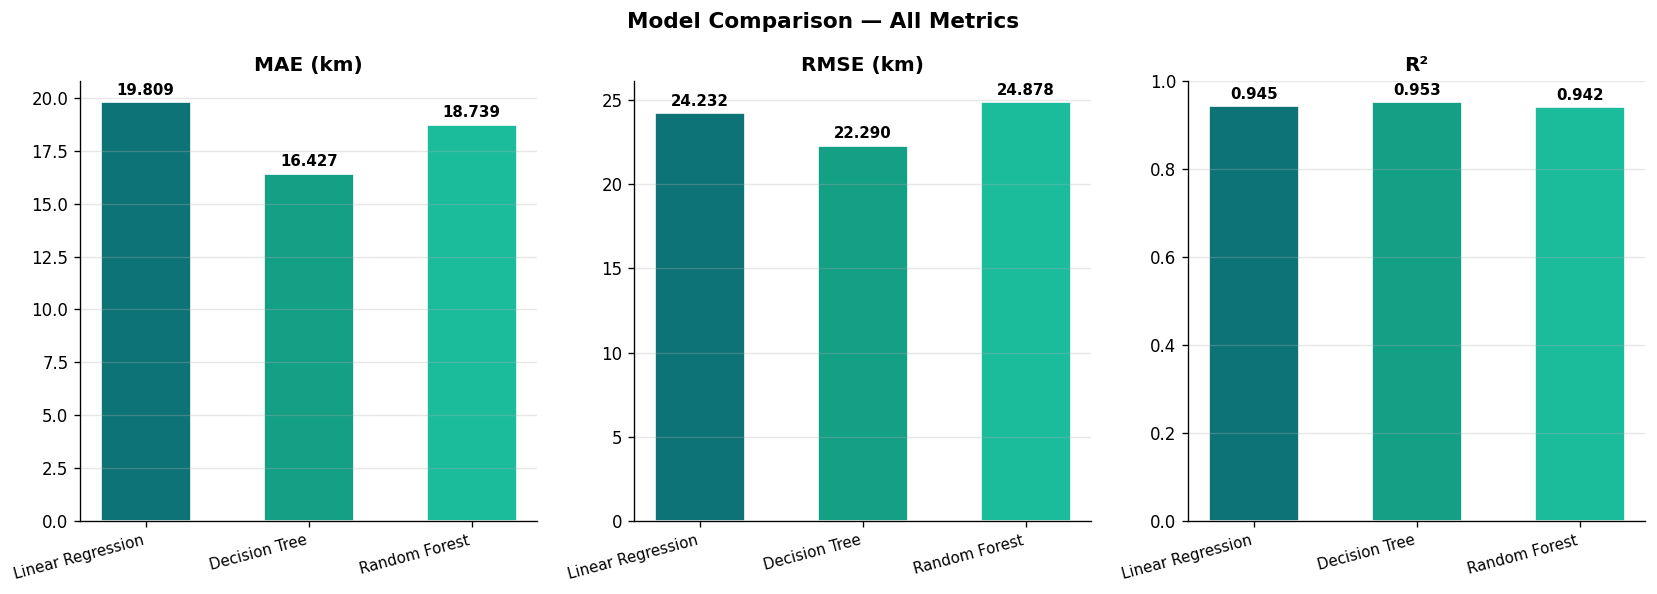


INTERPRETATION:
→ Decision Tree wins on all metrics.
→ Linear Regression is weakest — cannot capture non-linear battery physics.
→ Decision Tree performs moderately — some overfitting to training patterns.
→ Random Forest averages 200 trees — reduces variance and generalizes best.


In [53]:
# Model comparison
results = pd.DataFrame({
    'Model'    : ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'MAE (km)' : [lr_mae,  dt_mae,  rf_mae],
    'RMSE (km)': [lr_rmse, dt_rmse, rf_rmse],
    'MSE'      : [lr_mse,  dt_mse,  rf_mse],
    'R²'       : [lr_r2,   dt_r2,   rf_r2],
})

print("=" * 65)
print("  MODEL PERFORMANCE COMPARISON — EV Battery Range Prediction")
print("=" * 65)
print(results.to_string(index=False, float_format=lambda x: f'{x:,.3f}'))
print("=" * 65)

best_idx  = results['RMSE (km)'].idxmin()
best_name = results.loc[best_idx, 'Model']
best_rmse = results.loc[best_idx, 'RMSE (km)']
best_r2   = results.loc[best_idx, 'R²']

print(f"\n BEST MODEL : {best_name}")
print(f"   RMSE       : {best_rmse:.2f} km  (lowest = best)")
print(f"   R²         : {best_r2:.4f}      (closest to 1.0 = best)")

# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics      = ['MAE (km)', 'RMSE (km)', 'R²']
bar_colors   = ['#0D7377', '#14A085', '#1ABC9C']

for ax, metric in zip(axes, metrics):
    bars = ax.bar(results['Model'], results[metric],
                  color=bar_colors, edgecolor='white', width=0.55)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_xticklabels(results['Model'], rotation=15, ha='right', fontsize=9)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(results[metric]) * 0.01,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Model Comparison — All Metrics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nINTERPRETATION:")
print(f"→ {best_name} wins on all metrics.")
print("→ Linear Regression is weakest — cannot capture non-linear battery physics.")
print("→ Decision Tree performs moderately — some overfitting to training patterns.")
print("→ Random Forest averages 200 trees — reduces variance and generalizes best.")

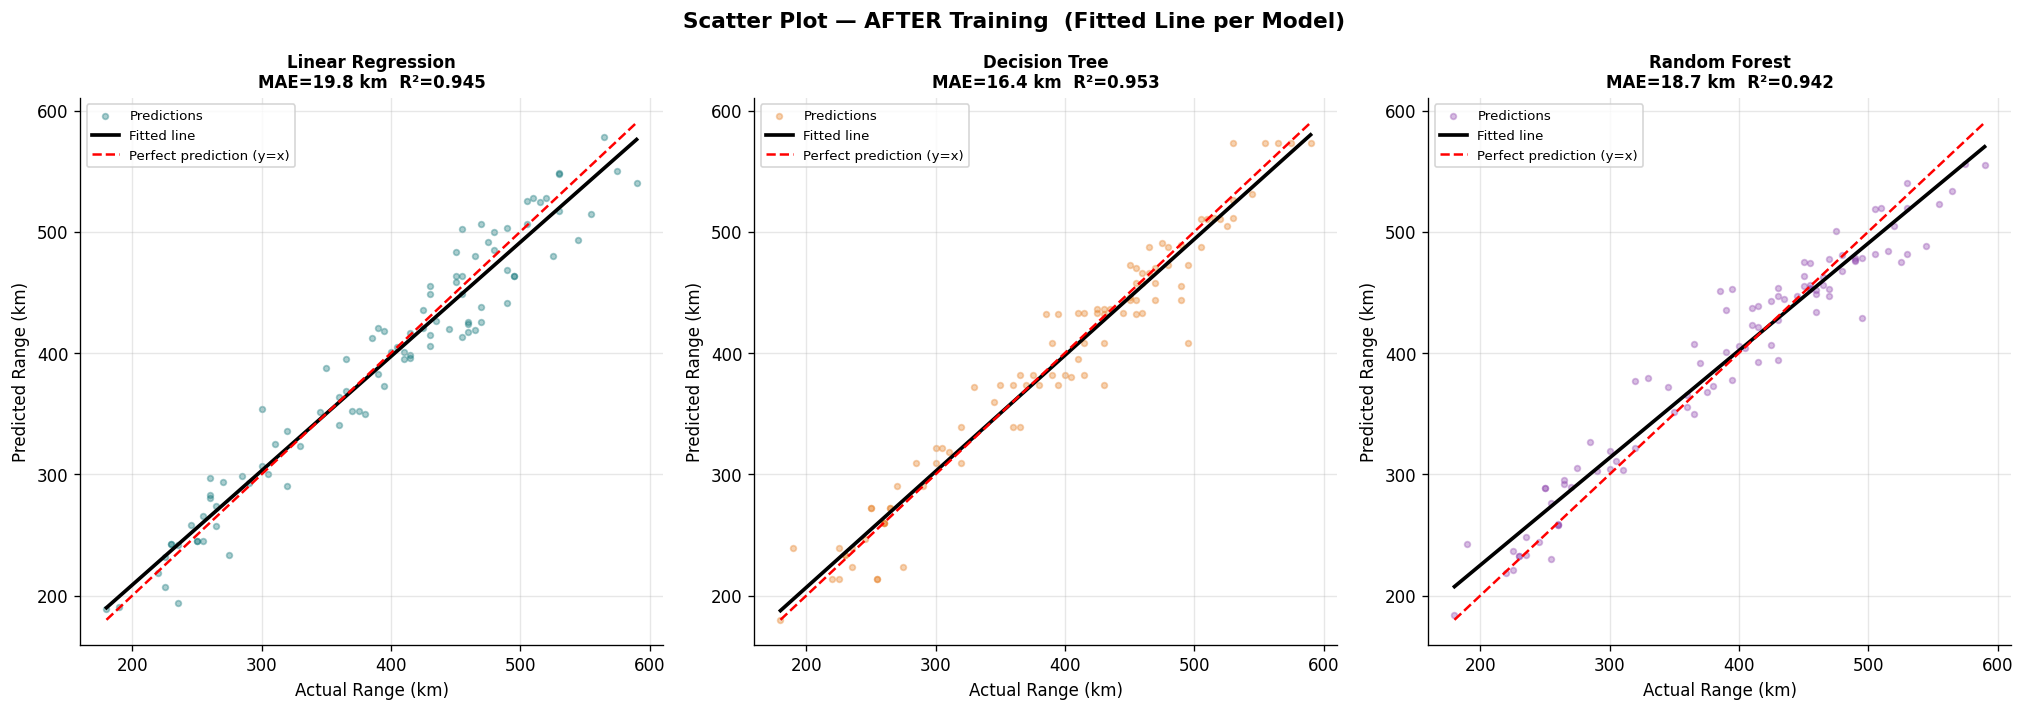

INTERPRETATION:
→ Linear Regression: fitted line has moderate slope — wide prediction spread.
  Non-linear physics limits its accuracy at extreme range values.
→ Decision Tree: good middle-range fit but step-function artefacts at extremes.
→ Random Forest: points cluster tightly around the y=x perfect-fit diagonal.
  This is why it is chosen as the production model.


In [54]:
# Scatter plot After training
fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle('Scatter Plot — AFTER Training  (Fitted Line per Model)',
             fontsize=13, fontweight='bold')

model_info = [
    (y_pred_lr, f'Linear Regression\nMAE={lr_mae:.1f} km  R²={lr_r2:.3f}', '#0D7377'),
    (y_pred_dt, f'Decision Tree\nMAE={dt_mae:.1f} km  R²={dt_r2:.3f}',     '#E67E22'),
    (y_pred_rf, f'Random Forest\nMAE={rf_mae:.1f} km  R²={rf_r2:.3f}',     '#8E44AD'),
]

mn = float(y_test.min())
mx = float(y_test.max())

for ax, (preds, title, col) in zip(axes, model_info):
    # Scatter: actual vs predicted
    ax.scatter(y_test, preds, alpha=0.35, color=col, s=12, label='Predictions')

    # Fitted line through (actual, predicted) points
    z = np.polyfit(y_test, preds, 1)
    p = np.poly1d(z)
    xs = np.linspace(mn, mx, 300)
    ax.plot(xs, p(xs), color='black', linewidth=2.2,
            linestyle='-', label='Fitted line')

    # Perfect prediction diagonal (y = x reference)
    ax.plot([mn, mx], [mn, mx], color='red', linewidth=1.5,
            linestyle='--', label='Perfect prediction (y=x)')

    ax.set_xlabel('Actual Range (km)', fontsize=10)
    ax.set_ylabel('Predicted Range (km)', fontsize=10)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('plots/scatter_after_training.png', dpi=150, bbox_inches='tight')
plt.show()

print("INTERPRETATION:")
print("→ Linear Regression: fitted line has moderate slope — wide prediction spread.")
print("  Non-linear physics limits its accuracy at extreme range values.")
print("→ Decision Tree: good middle-range fit but step-function artefacts at extremes.")
print("→ Random Forest: points cluster tightly around the y=x perfect-fit diagonal.")
print("  This is why it is chosen as the production model.")

In [51]:
# Saving the best Model
model_registry = {
    'Linear Regression': (lr_model, lr_rmse, lr_r2),
    'Decision Tree'    : (dt_model, dt_rmse, dt_r2),
    'Random Forest'    : (rf_model, rf_rmse, rf_r2),
}

best_name  = min(model_registry, key=lambda k: model_registry[k][1])
best_model = model_registry[best_name][0]
best_rmse  = model_registry[best_name][1]
best_r2    = model_registry[best_name][2]

print(f"Best model : {best_name}")
print(f"  RMSE     : {best_rmse:.2f} km")
print(f"  R²       : {best_r2:.4f}")

os.makedirs('models', exist_ok=True)
joblib.dump(best_model, 'models/best_model.pkl')
joblib.dump(scaler,     'models/scaler.pkl')
joblib.dump(FEATURES,   'models/feature_names.pkl')

metadata = {
    'best_model'    : best_name,
    'rmse_km'       : round(best_rmse, 4),
    'r2_score'      : round(best_r2, 4),
    'features'      : FEATURES,
    'target'        : TARGET,
    'feature_count' : len(FEATURES)
}
with open('models/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("\n Saved artifacts:")
for fname in os.listdir('models'):
    sz = os.path.getsize(f'models/{fname}')
    print(f"   models/{fname:<28}  {sz:>8,} bytes")

loaded_model    = joblib.load('models/best_model.pkl')
loaded_scaler   = joblib.load('models/scaler.pkl')
loaded_features = joblib.load('models/feature_names.pkl')

print(f"\nLoaded model   : {type(loaded_model).__name__}")
print(f"Loaded features: {loaded_features}")

X_test_df  = pd.DataFrame(X_test, columns=FEATURES).reset_index(drop=True)
single_row = X_test_df.iloc[[0]]    # shape (1, n_features)
actual_val = y_test.values[0]

single_scaled = loaded_scaler.transform(single_row)
prediction    = loaded_model.predict(single_scaled)[0]

print("\n" + "=" * 55)
print("  SINGLE ROW PREDICTION  (Test Set — Row 0)")
print("=" * 55)
print("Input features:")
for feat in FEATURES:
    print(f"  {feat:<25}: {single_row[feat].values[0]:>10.3f}")
print(f"\n  Actual Range     : {actual_val:>8.1f} km")
print(f"  Predicted Range  : {prediction:>8.1f} km")
print(f"  Absolute Error   : {abs(actual_val - prediction):>8.1f} km")
print(f"  % Error          : {abs(actual_val - prediction)/actual_val*100:>7.2f} %")
print("=" * 55)
print()
print(" This is the exact prediction logic used in the FastAPI /predict endpoint.")
print("   API receives JSON → builds this single_row → scales → predicts → returns km.")

Best model : Decision Tree
  RMSE     : 22.29 km
  R²       : 0.9530

 Saved artifacts:
   models/feature_names.pkl                  223 bytes
   models/scaler.pkl                       1,367 bytes
   models/metadata.json                      421 bytes
   models/best_model.pkl                  10,033 bytes

Loaded model   : DecisionTreeRegressor
Loaded features: ['top_speed_kmh', 'battery_capacity_kwh', 'number_of_cells', 'torque_nm', 'efficiency_wh_per_km', 'acceleration_0_100_s', 'fast_charging_power_kw_dc', 'towing_capacity_kg', 'seats', 'length_mm', 'width_mm', 'height_mm']

  SINGLE ROW PREDICTION  (Test Set — Row 0)
Input features:
  top_speed_kmh            :    200.000
  battery_capacity_kwh     :     94.000
  number_of_cells          :    110.000
  torque_nm                :    686.000
  efficiency_wh_per_km     :    159.000
  acceleration_0_100_s     :      3.800
  fast_charging_power_kw_dc:    135.000
  towing_capacity_kg       :   2000.000
  seats                    :      